# 🏭 MES Multi-Agent AI System
> **Architecture:** General Orchestrator Agent (Deva) ↔ System Data Agent (Read-Only DB)
>
> - **General Agent (Deva)** — understands intent, decides whether DB data is needed, synthesizes final answers.
> - **System Agent** — holds read-only SQL Server access, writes T-SQL, executes via tools, returns raw results.
> - **No data modification is possible** — only SELECT queries are permitted.


In [1]:
# CELL 1: Install / verify dependencies
import sys
!{sys.executable} -m pip install -q \
    langchain langchain-core langchain-community langchain-litellm \
    langgraph litellm sqlalchemy pyodbc pandas python-dotenv

print("✅ All dependencies installed.")


✅ All dependencies installed.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2: Imports, Environment & LLM Initialization (with Groq fallback)
import os
import json
import operator
import pandas as pd
from typing import Annotated, Sequence, TypedDict, Any
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
from dotenv import load_dotenv

import litellm
from langchain_litellm import ChatLiteLLM
from langchain_core.messages import (
    BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
)
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

load_dotenv()
litellm.set_verbose = False

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY   = os.getenv("GROQ_API_KEY")

# ── Primary LLMs: Gemini 3.6 Flash ───────────────────────────────────────
# NOTE: temperature removed — Gemini 3+ uses system prompt for sampling guidance
orchestrator_llm_primary = ChatLiteLLM(
    model="gemini/gemini-3.6-flash",
    api_key=GEMINI_API_KEY,
)

system_llm_primary = ChatLiteLLM(
    model="gemini/gemini-3.6-flash",
    api_key=GEMINI_API_KEY,
)

# ── Fallback LLMs: Groq (llama-3.3-70b) ──────────────────────────────────
orchestrator_llm_fallback = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
)

system_llm_fallback = ChatLiteLLM(
    model="groq/llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
)

# ── Resilient invoke helpers ──────────────────────────────────────────────
_ACTIVE_PROVIDER = {"orchestrator": "gemini", "system": "gemini"}

def invoke_with_fallback(primary_llm, fallback_llm, messages: list, role: str, tools=None):
    """
    Try primary LLM (Gemini). If it fails for any reason (rate limit, 404, timeout),
    automatically fall back to Groq — no data loss, same messages passed through.
    """
    global _ACTIVE_PROVIDER
    llm_primary  = primary_llm.bind_tools(tools)  if tools else primary_llm
    llm_fallback = fallback_llm.bind_tools(tools) if tools else fallback_llm

    try:
        result = llm_primary.invoke(messages)
        if _ACTIVE_PROVIDER[role] != "gemini":
            print(f"   [ROUTER] {role.title()} recovered to Gemini.")
        _ACTIVE_PROVIDER[role] = "gemini"
        return result
    except Exception as e:
        err_str = str(e)
        print(f"   [ROUTER] Gemini failed for {role}: {err_str[:120]}")
        print(f"   [ROUTER] Falling back to Groq for {role}...")
        _ACTIVE_PROVIDER[role] = "groq"
        try:
            result = llm_fallback.invoke(messages)
            print(f"   [ROUTER] Groq responded successfully for {role}.")
            return result
        except Exception as e2:
            raise RuntimeError(
                f"Both Gemini and Groq failed for {role}.\n"
                f"Gemini error: {err_str[:200]}\n"
                f"Groq error: {str(e2)[:200]}"
            ) from e2

print("✅ LLMs initialized — Primary: Gemini 3.6 Flash | Fallback: Groq llama-3.3-70b")
print("   Auto-failover enabled: Gemini → Groq (zero data loss)")


c:\Users\renuk\AppData\Local\Programs\Python\Python310\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ LLMs initialized — Primary: Gemini 3.6 Flash | Fallback: Groq llama-3.3-70b
   Auto-failover enabled: Gemini → Groq (zero data loss)


In [3]:
# CELL 3: Database Engine — Read-Only Windows Authentication
DB_DRIVER     = os.getenv("DB_DRIVER",                  "ODBC Driver 18 for SQL Server")
DB_SERVER     = os.getenv("DB_SERVER",                  "localhost")
DB_NAME       = os.getenv("DB_NAME",                    "mes_new")
DB_TRUSTED    = os.getenv("DB_TRUSTED_CONNECTION",      "yes")
DB_ENCRYPT    = os.getenv("DB_ENCRYPT",                 "yes")
DB_TRUST_CERT = os.getenv("DB_TRUST_SERVER_CERTIFICATE","yes")

conn_str = (
    f"DRIVER={{{DB_DRIVER}}};SERVER={DB_SERVER};DATABASE={DB_NAME};"
    f"Trusted_Connection={DB_TRUSTED};Encrypt={DB_ENCRYPT};"
    f"TrustServerCertificate={DB_TRUST_CERT};"
)
connection_url = f"mssql+pyodbc:///?odbc_connect={quote_plus(conn_str)}"

try:
    engine = create_engine(connection_url, echo=False)
    with engine.connect() as conn:
        db_name_result = conn.execute(text("SELECT DB_NAME() AS db"))
        db_name_val    = db_name_result.fetchone()[0]
    print(f"✅ Connected to SQL Server — Database: [{db_name_val}]")
    print(f"   Server: {DB_SERVER} | Auth: Windows (Trusted)")
except Exception as e:
    print(f"❌ Database connection FAILED: {e}")
    engine = None


✅ Connected to SQL Server — Database: [mes_new]
   Server: localhost | Auth: Windows (Trusted)


In [4]:
# CELL 4: MES Schema Catalog — Tables exposed for read-only access
MES_CATALOG = {
    # Machines & Capacity
    "Machine": [
        "MachineId","MachineName","MachineCode","MachineType","Model",
        "Status","Capacity","LastServiceDate","NextServiceDue",
        "ProductionPerDay","CompanyId"
    ],
    "MachineMaster": [
        "MachineId","MachineCode","MachineName","MachineType","Location",
        "CapacityPerHour","AvailableHoursPerDay","EfficiencyPercent","Status",
        "IsActive","CustomerId","Capacity","MinCapacity","MaxCapacity",
        "LastMaintDate","NextMaintDate","Shift","Utilization","WorkCenter"
    ],
    "CapacityAnalysis": [
        "CapacityId","MachineId","Date","ShiftId","AvailableHours",
        "PlannedHours","ActualHours","UtilizationPercent","OverloadFlag","CustomerId"
    ],
    # Work Orders & Scheduling
    "WorkOrderMaster": [
        "WorkOrderId","WorkOrderNumber","ProductId","Quantity",
        "PlannedStartDate","PlannedEndDate","ActualStartDate","ActualEndDate",
        "Status","Priority","MachineId","CustomerId","CreatedDate"
    ],
    "GanttSchedule": [
        "GanttId","WorkOrderId","MachineId","StartDate","EndDate",
        "Duration","Progress","Dependencies","CustomerId","BarStatus"
    ],
    # Inventory & Materials
    "Inventory": [
        "Id","MaterialCode","Category","BlockedQuantity",
        "QuantityInStock","UpdatedOn","CompanyId"
    ],
    "InventoryByLot": [
        "InventoryId","ProductId","LotId","WarehouseCode","LocationCode",
        "Quantity","ReservedQty","AvailableQty","LastUpdated","CustomerId"
    ],
    "FinishedGood": [
        "FGId","RequestId","MaterialCode","MaterialName","Quantity","FGQuantity",
        "BlockedQuantity","NumberOfBags","KGInPerBags","StoreId","UOM",
        "Status","CompanyId","Color","IsDispatch"
    ],
    "LotMaster": [
        "LotId","LotNumber","ProductId","ManufactureDate",
        "ExpiryDate","Status","CustomerId"
    ],
    # Products & BOM
    "ProductMaster": [
        "ProductId","ProductCode","ProductName","Category","UOM","StdCost","IsActive","CustomerId"
    ],
    "BOMMaster": [
        "BOMId","ProductId","BOMVersion","EffectiveFrom","EffectiveTo","Status","IsActive","CustomerId"
    ],
    "BOMLine": [
        "BOMLineId","BOMId","ComponentId","Quantity","UOM","Sequence","ScrapPercent","IsActive","CustomerId"
    ],
    # Quality & Alerts
    "AlertMaster": [
        "AlertId","AlertType","Severity","Title","Message","Source",
        "WorkOrderId","MachineId","IsAcknowledged","IsResolved","CreatedDate","CustomerId"
    ],
}

SCHEMA_CONTEXT = "\n".join(
    f"  [{tbl}]: {', '.join(cols)}"
    for tbl, cols in MES_CATALOG.items()
)

print(f"✅ MES Schema Catalog loaded — {len(MES_CATALOG)} tables exposed for read-only access:")
for tbl in MES_CATALOG:
    print(f"   • {tbl}")


✅ MES Schema Catalog loaded — 13 tables exposed for read-only access:
   • Machine
   • MachineMaster
   • CapacityAnalysis
   • WorkOrderMaster
   • GanttSchedule
   • Inventory
   • InventoryByLot
   • FinishedGood
   • LotMaster
   • ProductMaster
   • BOMMaster
   • BOMLine
   • AlertMaster


In [5]:
# CELL 5: System Agent Tools — Read-Only SQL Execution + Schema Lookup
BLOCKED_SQL_KEYWORDS = [
    "DROP","DELETE","UPDATE","INSERT","ALTER",
    "TRUNCATE","EXEC","EXECUTE","CREATE","MERGE",
    "GRANT","REVOKE","DENY","BACKUP","RESTORE","XP_","SP_"
]

@tool
def execute_read_only_sql(query: str) -> str:
    """
    Executes a T-SQL SELECT query against the MES SQL Server database (read-only).
    Use this tool to answer questions about:
      - Work Orders, production schedules, Gantt charts
      - Machine status, capacity, efficiency, OEE
      - Inventory levels (raw materials, finished goods, by-lot)
      - Quality checks, scrap records
      - Alerts and maintenance
    Returns JSON results (max 50 rows). ONLY SELECT queries are allowed.
    """
    if engine is None:
        return "Database engine not initialized. Check your .env connection settings."
    upper_q = query.upper().strip()
    for kw in BLOCKED_SQL_KEYWORDS:
        if kw in upper_q:
            return (
                f"SECURITY EXCEPTION: keyword '{kw}' is not allowed. "
                "System Agent is restricted to SELECT queries only."
            )
    if not upper_q.startswith("SELECT"):
        return "SECURITY EXCEPTION: Only SELECT queries are permitted."
    try:
        with engine.connect() as conn:
            df = pd.read_sql_query(query, conn)
        if df.empty:
            return "Query ran successfully — no matching records found."
        result_json = df.head(50).to_json(orient="records", date_format="iso", indent=2)
        note = f"\n[Showing 50 of {len(df)} rows]" if len(df) > 50 else ""
        return result_json + note
    except Exception as e:
        return f"SQL Execution Error: {e}\nPlease revise the query."


@tool
def get_mes_schema_details(table_name: str) -> str:
    """
    Returns the allowed columns for a specific MES database table.
    Use BEFORE writing SQL when you are unsure about column names.
    Example: get_mes_schema_details("MachineMaster")
    """
    if table_name in MES_CATALOG:
        cols = ", ".join(MES_CATALOG[table_name])
        return f"[dbo].[{table_name}] has columns: {cols}"
    available = ", ".join(MES_CATALOG.keys())
    return (
        f"Table '{table_name}' is not in the allowed schema. "
        f"Available tables: {available}"
    )


@tool
def list_available_tables() -> str:
    """
    Lists all MES database tables the System Agent has read-only access to.
    Use this when you need to know which tables are available.
    """
    table_list = ", ".join(MES_CATALOG.keys())
    return f"Available MES tables ({len(MES_CATALOG)}): {table_list}"


system_tools     = [execute_read_only_sql, get_mes_schema_details, list_available_tables]
system_tool_node = ToolNode(system_tools)

print(f"✅ System Agent tools registered:")
for t in system_tools:
    print(f"   • {t.name}")


✅ System Agent tools registered:
   • execute_read_only_sql
   • get_mes_schema_details
   • list_available_tables


In [6]:
# CELL 6: Agent State + Agent Definitions (with resilient LLM calls)
# ─────────────────────────────────────────────────────────────────────────────

class AgentState(TypedDict):
    messages:     Annotated[Sequence[BaseMessage], operator.add]
    active_agent: str


# ── GENERAL ORCHESTRATOR AGENT (Deva) ─────────────────────────────────────
GENERAL_SYSTEM_PROMPT = """You are **Deva**, the Manufacturing Intelligence Orchestrator for a Smart IIoT MES platform.

Your role:
1. Understand the user's manufacturing query (production, machines, inventory, quality, OEE, scheduling, etc.).
2. If you need real-time data from the MES database, include the phrase [SYSTEM_AGENT] in your response followed by the specific data you need.
   The routing logic will automatically delegate to the System Data Agent.
3. Once the System Agent returns raw JSON data, analyze it with manufacturing domain expertise and present:
   - A concise executive summary with key KPIs
   - Any anomalies, trends, or alerts worth flagging
   - Actionable recommendations for the factory team

Rules:
- NEVER write SQL yourself — that is strictly the System Agent responsibility.
- If the question can be answered with general manufacturing knowledge, answer directly without DB access.
- Always be professional, precise, and data-driven.
"""

def general_orchestrator(state: AgentState) -> dict:
    """General Agent (Deva): Orchestrates queries and synthesizes final responses."""
    sys_msg  = SystemMessage(content=GENERAL_SYSTEM_PROMPT)
    messages = [sys_msg] + list(state["messages"])
    response = invoke_with_fallback(
        orchestrator_llm_primary,
        orchestrator_llm_fallback,
        messages,
        role="orchestrator"
    )
    return {"messages": [response], "active_agent": "general"}


# ── SYSTEM DATA AGENT ────────────────────────────────────────────────────
SYSTEM_AGENT_PROMPT = f"""You are the MES System Data Agent — a strictly-scoped database interface with READ-ONLY access.

Responsibilities:
1. Parse the data request from the General Agent.
2. Use get_mes_schema_details or list_available_tables when you need schema info.
3. Write a precise T-SQL SELECT using [dbo].[TableName] fully qualified syntax.
4. Execute it using execute_read_only_sql.
5. Return the raw JSON results — do NOT interpret or analyze the data yourself.

HARD RULES:
  Only SELECT queries allowed.
  Never use: INSERT, UPDATE, DELETE, DROP, ALTER, EXEC, CREATE, MERGE.
  Never expose credentials.
  Add TOP 50 to all queries to limit rows.

Available Schema:
{SCHEMA_CONTEXT}

SQL Style Guide:
  - [dbo].[TableName] fully qualified names
  - Add TOP 50 to every query
  - Use GETDATE() for current-time references
  - Use DATEADD(day, -7, GETDATE()) for last-week filters
"""

def system_data_agent(state: AgentState) -> dict:
    """System Agent: Translates data requests to SQL and executes with read-only access."""
    sys_msg  = SystemMessage(content=SYSTEM_AGENT_PROMPT)
    messages = [sys_msg] + list(state["messages"])
    response = invoke_with_fallback(
        system_llm_primary,
        system_llm_fallback,
        messages,
        role="system",
        tools=system_tools
    )
    return {"messages": [response], "active_agent": "system"}


print("✅ Agents defined: General (Deva) + System Data Agent")
print("   Both agents use resilient Gemini → Groq auto-failover.")


✅ Agents defined: General (Deva) + System Data Agent
   Both agents use resilient Gemini → Groq auto-failover.


In [7]:
# CELL 7: Graph Routing Logic
# ────────────────────────────────────────────────────────────────────────────

# Keywords/phrases that trigger delegation from General to System Agent
_DELEGATION_TRIGGERS = [
    "[system_agent]",
    "fetch data", "query the", "retrieve from", "database",
    "from the db", "select from", "check the table", "look up",
    "get records", "pull data", "data shows", "query database",
    "fetch from", "get the data", "need to query", "need data from"
]

def route_from_general(state: AgentState) -> str:
    """
    After the General Agent responds:
      -> 'system'  : if the message signals a data delegation request
      -> END       : if the response is the final answer to the user
    """
    last_msg = state["messages"][-1]
    content  = (getattr(last_msg, "content", "") or "").lower()
    if any(trigger in content for trigger in _DELEGATION_TRIGGERS):
        return "system"
    return END


def route_from_system(state: AgentState) -> str:
    """
    After the System Agent responds:
      -> 'tools'   : if it called a SQL / schema tool (tool_calls present)
      -> 'general' : if it finished retrieving data (return to General for synthesis)
    """
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "general"


print("✅ Graph routing functions defined.")


✅ Graph routing functions defined.


✅ MES Multi-Agent Graph compiled successfully!

  Architecture:
  START → [General: Deva] ──(needs data?)──► [System Agent] ──► [Tool Executor]
              ↑                                      │
              └────────── (data returned) ◄──────────┘
  END ◄── [General: final synthesis to user]



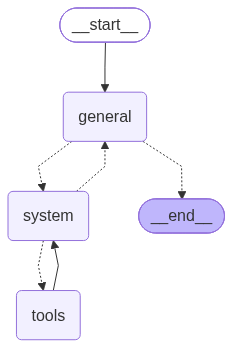

In [8]:
# CELL 8: Build & Compile the LangGraph
# ────────────────────────────────────────────────────────────────────────────
builder = StateGraph(AgentState)

# Register nodes
builder.add_node("general", general_orchestrator)  # Deva - Orchestrator
builder.add_node("system",  system_data_agent)      # System - DB Agent
builder.add_node("tools",   system_tool_node)       # SQL / schema Tool Executor

# Entry point
builder.add_edge(START, "general")

# Conditional routing after General Agent
builder.add_conditional_edges(
    "general",
    route_from_general,
    {"system": "system", END: END}
)

# Conditional routing after System Agent
builder.add_conditional_edges(
    "system",
    route_from_system,
    {"tools": "tools", "general": "general"}
)

# After tools finish, always return to System Agent
builder.add_edge("tools", "system")

# Compile
mes_agent_app = builder.compile()

print("✅ MES Multi-Agent Graph compiled successfully!")
print()
print("  Architecture:")
print("  START → [General: Deva] ──(needs data?)──► [System Agent] ──► [Tool Executor]")
print("              ↑                                      │")
print("              └────────── (data returned) ◄──────────┘")
print("  END ◄── [General: final synthesis to user]")
print()

try:
    from IPython.display import Image, display
    display(Image(mes_agent_app.get_graph().draw_mermaid_png()))
except Exception:
    print("  (Install pygraphviz to render agent graph diagram)")

In [9]:
# CELL 9: Interactive Query Runner Helper
# ────────────────────────────────────────────────────────────────────────────

def run_mes_query(user_question: str, verbose: bool = True) -> str:
    """
    Run a natural-language query through the MES Multi-Agent system.

    Args:
        user_question : Plain-English question about manufacturing operations.
        verbose       : If True, print step-by-step agent trace.

    Returns:
        Final synthesized answer string from Deva (General Agent).
    """
    sep  = "=" * 70
    dash = "-" * 70

    print(f"\n{sep}")
    print("  MANUFACTURING AI — MES QUERY")
    print(f"  User: {user_question}")
    print(dash)

    initial_state = {
        "messages":     [HumanMessage(content=user_question)],
        "active_agent": "general"
    }

    final_answer = ""
    icons = {"general": "[GENERAL/DEVA]", "system": "[SYSTEM/DB]", "tools": "[TOOL EXEC]"}

    for event in mes_agent_app.stream(initial_state, {"recursion_limit": 15}):
        for node_name, state_update in event.items():
            if "messages" not in state_update:
                continue

            latest_msg = state_update["messages"][-1]

            if verbose:
                label = icons.get(node_name, f"[{node_name.upper()}]")
                print(f"\n  {label}")

                # Tool call trace
                if hasattr(latest_msg, "tool_calls") and latest_msg.tool_calls:
                    for tc in latest_msg.tool_calls:
                        print(f"    >> Tool called: {tc['name']}")
                        args_preview = str(tc.get("args", ""))[:250]
                        print(f"       Args: {args_preview}")

                # Tool execution result
                elif isinstance(latest_msg, ToolMessage):
                    preview = (latest_msg.content or "")[:400]
                    print(f"    >> DB Result (preview): {preview}...")

                # Regular AI message
                elif hasattr(latest_msg, "content") and latest_msg.content:
                    content_preview = latest_msg.content[:600]
                    print(f"    >> {content_preview}")

            # Capture the General Agent's final response
            if node_name == "general" and hasattr(latest_msg, "content"):
                final_answer = latest_msg.content

    print(f"\n{sep}")
    print("  FINAL ANSWER FROM DEVA")
    print(sep)
    print(final_answer)
    print(f"{sep}\n")
    return final_answer


print("✅ run_mes_query() helper is ready to use.")


✅ run_mes_query() helper is ready to use.


In [10]:
# CELL 10: Run Your Query Here!
# ────────────────────────────────────────────────────────────────────────────
# Edit user_question below and run this cell.

user_question = (
    "Identify any machines where the EfficiencyPercent is below 90% "
    "and show me their current Capacity Utilization from the CapacityAnalysis table."
)

answer = run_mes_query(user_question, verbose=True)



  MANUFACTURING AI — MES QUERY
  User: Identify any machines where the EfficiencyPercent is below 90% and show me their current Capacity Utilization from the CapacityAnalysis table.
----------------------------------------------------------------------

  [GENERAL/DEVA]
    >> To retrieve this information, I will query our MES database for the relevant machine performance metrics.

[SYSTEM_AGENT] Please retrieve the machine IDs/names, EfficiencyPercent, and Capacity Utilization from the CapacityAnalysis table for all machines where EfficiencyPercent is strictly less than 90%.

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

   [ROUTER] Gemini failed for system: litellm.BadRequestError: GeminiException BadRequestError - {
  "error": {
    "code": 400,
    "message": "Requests endi
   [ROUTER] Falling back to Groq for system...
   [ROUTER] Groq responded successfully for system.

  [S

In [11]:
# CELL 11: More Example Queries
# ────────────────────────────────────────────────────────────────────────────
# Uncomment any line and run this cell to ask a different question.

# --- Inventory ---
# run_mes_query("What is the current inventory level for all materials? Flag any below minimum stock.")

# --- Work Orders ---
# run_mes_query("Show me all Work Orders with status 'In Progress' created in the last 7 days.")

# --- Scrap Analysis ---
# run_mes_query("Which machines had the highest scrap quantity last week? Show top 5.")

# --- Alerts ---
# run_mes_query("List all unresolved critical alerts from the AlertMaster table.")

# --- OEE ---
# run_mes_query("Give me OEE breakdown for all machines this month.")

# --- Maintenance ---
# run_mes_query("Which machines are due for maintenance in the next 7 days?")

# --- General Knowledge (no DB needed) ---
# run_mes_query("What is OEE and how is it calculated in a manufacturing context?")

print("Uncomment any example query above and re-run this cell.")


Uncomment any example query above and re-run this cell.
